# 02 — EDA : articles.csv + jointure transactions_train.csv

*Notebook*

> **Dépendances :** Nécessite le `customers.csv` nettoyé produit par **01_EDA_Nettoyage_Clients.ipynb** (recharger le CSV nettoyé exporté, ou ré-exécuter le notebook 01 dans la même session).


## 0. Reprise depuis le notebook précédent

Ce notebook nécessite `customers` (table nettoyée), exportée par **01_EDA_Nettoyage_Clients.ipynb**.
Exécute d'abord ce dernier (jusqu'à sa cellule d'export) sur le même `BASE_PATH`/Drive.

In [1]:
import os, pickle, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/HM_dataset/"
except ImportError:
    print("Google Colab non détecté -> lecture des fichiers dans le dossier courant.")
    BASE_PATH = "./"

CUSTOMERS_PATH = os.path.join(BASE_PATH, "customers.csv")
ARTICLES_PATH = os.path.join(BASE_PATH, "articles.csv")
TRANSACTIONS_PATH = os.path.join(BASE_PATH, "transactions_train.csv")
INTERMEDIATE_DIR = os.path.join(BASE_PATH, "intermediate/")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)

try:
    with open(os.path.join(INTERMEDIATE_DIR, "nb01_customers.pkl"), "rb") as f:
        customers = pickle.load(f)
    print(f"customers chargé depuis nb01_customers.pkl : {customers.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(
        "nb01_customers.pkl introuvable dans INTERMEDIATE_DIR. Exécute d'abord 01_EDA_Nettoyage_Clients.ipynb (jusqu'à sa dernière cellule d'export) sur le même BASE_PATH/Drive."
    ) from e


Mounted at /content/drive
customers chargé depuis nb01_customers.pkl : (1371980, 6)


# 8. Dataset produit : `articles.csv`

Une vraie jointure client ↔ produit n'est pas possible pour l'instant. On explore ici
`articles.csv` de façon autonome, comme catalogue produit H&M.


In [2]:
# ARTICLES_PATH déjà défini dans la section de configuration Colab/Drive ci-dessus
articles = pd.read_csv(ARTICLES_PATH, dtype={"article_id": "int64"})

print(f"Dimensions : {articles.shape[0]:,} lignes x {articles.shape[1]} colonnes")
articles.head()


Dimensions : 105,542 lignes x 25 colonnes


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [3]:
articles.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

## 8.1 Valeurs manquantes

In [4]:
missing_articles = articles.isnull().sum()
missing_articles = missing_articles[missing_articles > 0]
missing_articles_pct = (missing_articles / len(articles) * 100).round(2)
pd.DataFrame({"missing_count": missing_articles, "missing_pct": missing_articles_pct})


,missing_count,missing_pct
detail_desc,416,0.39


**Interprétation :** seule `detail_desc` (description textuelle) comporte des valeurs manquantes
(~0.4%), toutes les colonnes structurées (catégories, couleurs, sections) sont complètes.


## 8.2 Répartition par groupe de produit

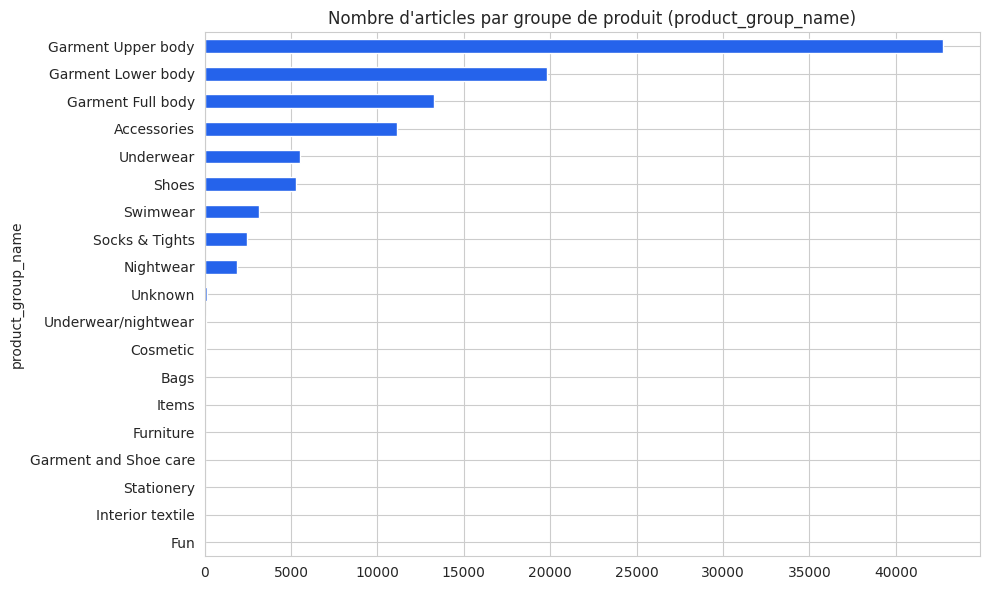

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
articles["product_group_name"].value_counts().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Nombre d'articles par groupe de produit (product_group_name)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** le catalogue est dominé par le **Garment Upper body** (hauts, ~40% du
catalogue) et le **Garment Lower body** (bas, ~19%), suivis par **Garment Full body** et
**Accessories**. Les catégories comme Furniture, Stationery ou Fun sont anecdotiques (quelques
unités), probablement des produits dérivés/déco plutôt que du textile.


## 8.3 Segment client visé (`index_name`)

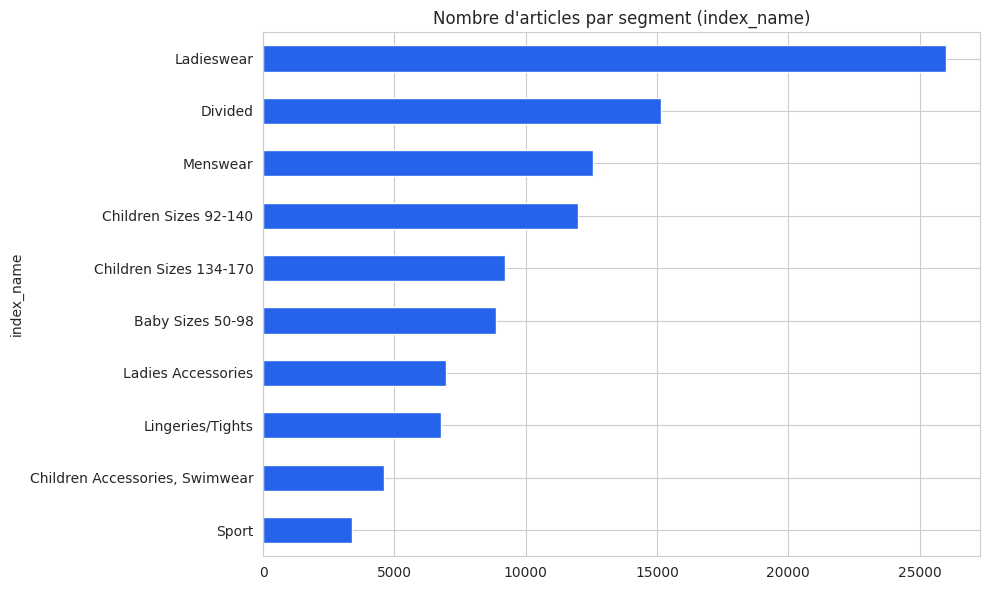

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
articles["index_name"].value_counts().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Nombre d'articles par segment (index_name)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** `Ladieswear` domine largement le catalogue (~26 000 articles), suivi de
`Divided` (mode jeune/tendance) et `Menswear`. Les segments enfants (Children Sizes 92-140,
134-170, Baby Sizes 50-98) représentent ensemble une part significative du catalogue, cohérent
avec le positionnement multi-segments de H&M (femme, homme, enfant, bébé).


## 8.4 Types de produits les plus représentés

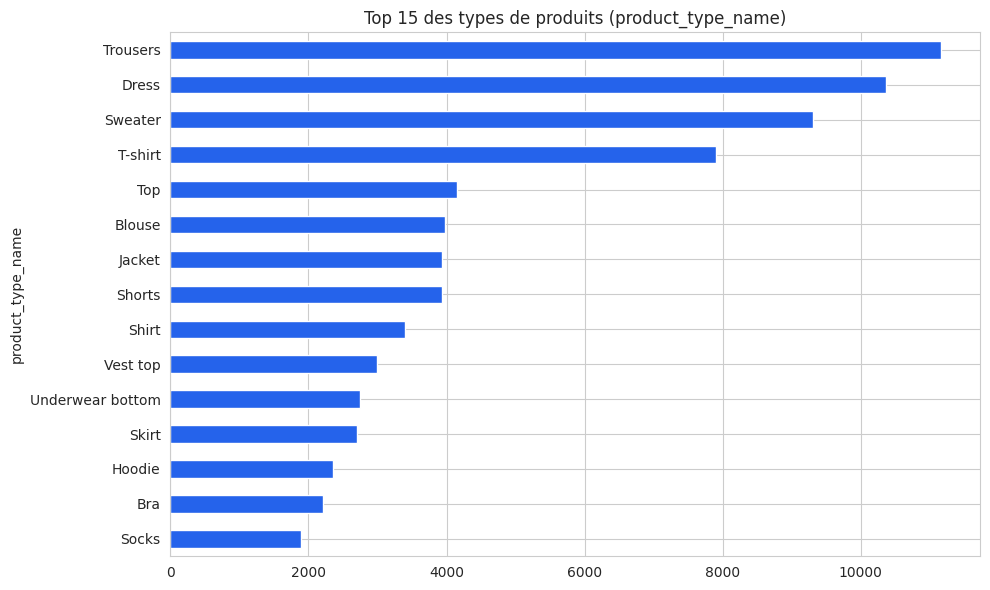

In [7]:
top_product_types = articles["product_type_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_product_types.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Top 15 des types de produits (product_type_name)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close('all')


In [8]:
print(f"Nombre de types de produits distincts : {articles['product_type_name'].nunique()}")
print(f"Nombre de départements distincts          : {articles['department_name'].nunique()}")
print(f"Nombre de sections distinctes              : {articles['section_name'].nunique()}")
print(f"Nombre de groupes de coupe distincts        : {articles['garment_group_name'].nunique()}")


Nombre de types de produits distincts : 131
Nombre de départements distincts          : 250
Nombre de sections distinctes              : 56
Nombre de groupes de coupe distincts        : 21


**Interprétation :** `Trousers`, `Dress`, `Sweater` et `T-shirt` sont les types de produits les plus fréquents dans le catalogue.

Avec 131 types de produits, 250 départements et 56 sections, le
catalogue H&M est très granulaire, utile pour du filtrage fin, mais nécessite souvent de regrouper ces catégories (via `product_group_name` ou `garment_group_name`, plus agrégés) pour des analyses lisibles.


## 8.5 Couleurs les plus fréquentes

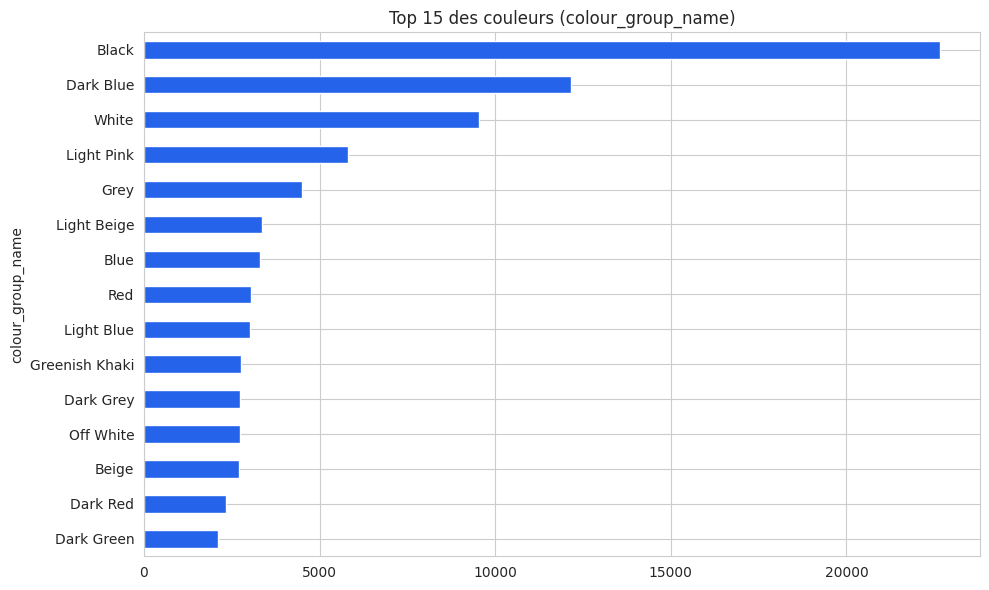

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
articles["colour_group_name"].value_counts().head(15).plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Top 15 des couleurs (colour_group_name)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** `Black`, `Dark Blue` et `White` dominent très largement, cohérent avec des
basiques intemporels vendus en continu, plus faciles à décliner sur l'ensemble des collections que
des couleurs saisonnières.


## 8.6 Croisement groupe de produit x segment client

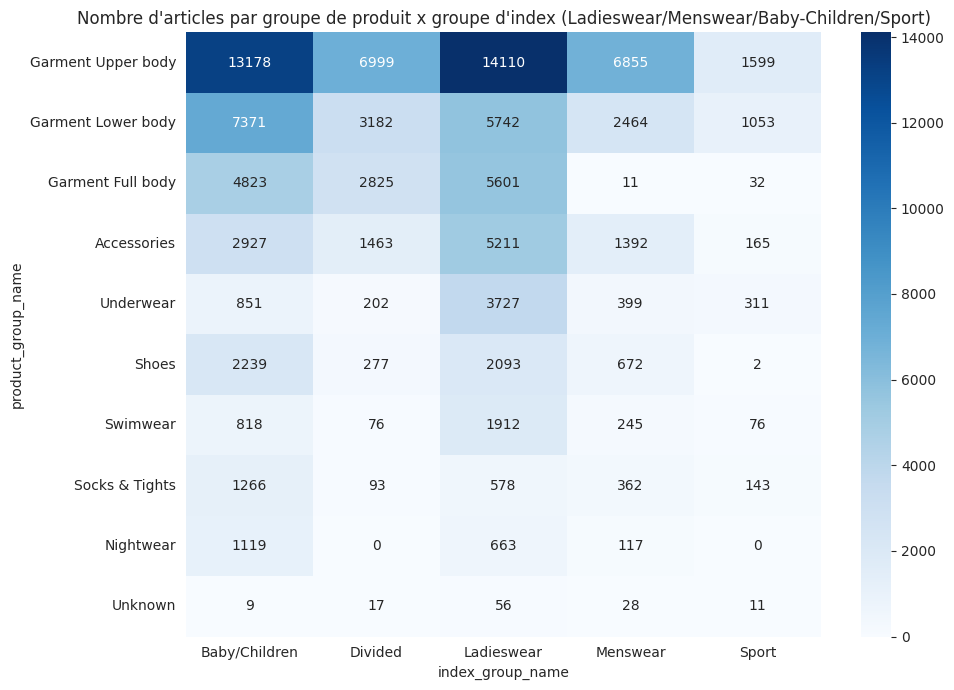

In [10]:
cross_product_index = pd.crosstab(articles["product_group_name"], articles["index_group_name"])
cross_product_index = cross_product_index.loc[
    articles["product_group_name"].value_counts().head(10).index
]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cross_product_index, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Nombre d'articles par groupe de produit x groupe d'index (Ladieswear/Menswear/Baby-Children/Sport)")
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** ce croisement confirme que les catégories `Garment Upper/Lower/Full body`
sont bien représentées dans tous les segments (Ladieswear, Menswear, Baby/Children), alors que
certaines catégories comme `Underwear` ou `Swimwear` sont plus concentrées sur des segments
spécifiques.


## 9. Jointure complète avec `transactions_train.csv`

`transactions_train.csv` est maintenant disponible en entier (33,7 millions de lignes, ~3,5 Go,
20/09/2018 → 22/09/2020).

Ce fichier dépasse la RAM disponible pour un chargement direct en une seule fois avec pandas : on le traite donc **par blocs (chunks)**, en fusionnant chaque bloc avec `customers` et `articles` (qui, eux, tiennent en mémoire), puis en accumulant les agrégats nécessaires (sommes, comptages) au fil des blocs.

C'est l'approche standard pour analyser un fichier
plus gros que la mémoire disponible, sans perdre en exactitude (contrairement à un simple
échantillonnage).


In [11]:
# TRANSACTIONS_PATH déjà défini dans la section de configuration Colab/Drive ci-dessus

# --- Tables de référence (petites, chargées entièrement en mémoire) ---
customers_small = customers[["customer_id", "age_group", "club_member_status"]].copy()
articles_small = articles[["article_id", "product_group_name", "prod_name"]].copy()

print(f"customers_small : {customers_small.memory_usage(deep=True).sum() / 1e6:.1f} Mo")
print(f"articles_small  : {articles_small.memory_usage(deep=True).sum() / 1e6:.1f} Mo")


customers_small : 232.2 Mo
articles_small  : 14.5 Mo


In [12]:
from collections import defaultdict
import time

CHUNK_SIZE = 2_000_000
dtypes_transactions = {
    "customer_id": "string",
    "article_id": "int64",
    "price": "float32",
    "sales_channel_id": "int8",
}

# Accumulateurs (dictionnaires simples : robustes et peu coûteux en mémoire)
price_sum_by_age = defaultdict(float)
count_by_age = defaultdict(int)
count_by_age_category = defaultdict(int)          # clé : (age_group, product_group_name)
count_by_status = defaultdict(int)
price_sum_by_status = defaultdict(float)
customers_seen_by_status = defaultdict(set)        # clients distincts ayant acheté, par statut
article_counts = defaultdict(int)                  # nb de ventes par article_id
channel_counts = defaultdict(int)
weekly_counts = defaultdict(int)                   # nb de transactions par semaine

# --- Accumulateurs : RFM client + revenu quotidien + revenu par catégorie ---
customer_stats = defaultdict(lambda: [0.0, 0])     # customer_id -> [montant_total, nb_achats]
daily_revenue = defaultdict(float)                 # date -> chiffre d'affaires (CA) du jour
daily_count = defaultdict(int)                     # date -> nb de transactions du jour
product_group_revenue = defaultdict(float)         # product_group_name -> CA total

# --- Accumulateurs pour le feature engineering (section 14) : récence, ancienneté, diversité ---
customer_min_date = {}                             # customer_id -> date du 1er achat
customer_max_date = {}                             # customer_id -> date du dernier achat
customer_categories = defaultdict(set)             # customer_id -> {product_group_name achetés}

total_rows = 0

t0 = time.time()
reader = pd.read_csv(
    TRANSACTIONS_PATH, dtype=dtypes_transactions, parse_dates=["t_dat"], chunksize=CHUNK_SIZE
)

for i, chunk in enumerate(reader):
    total_rows += len(chunk)
    chunk = chunk.merge(customers_small, on="customer_id", how="left")
    chunk = chunk.merge(articles_small, on="article_id", how="left")

    for ag, price in zip(chunk["age_group"], chunk["price"]):
        price_sum_by_age[ag] += price
        count_by_age[ag] += 1

    for ag, pg in zip(chunk["age_group"], chunk["product_group_name"]):
        count_by_age_category[(ag, pg)] += 1

    for status, price, cid in zip(chunk["club_member_status"], chunk["price"], chunk["customer_id"]):
        count_by_status[status] += 1
        price_sum_by_status[status] += price
        customers_seen_by_status[status].add(cid)

    for aid, cnt in chunk["article_id"].value_counts().items():
        article_counts[aid] += cnt

    for ch, cnt in chunk["sales_channel_id"].value_counts().items():
        channel_counts[ch] += cnt

    for w, cnt in chunk.set_index("t_dat").resample("W").size().items():
        weekly_counts[w] += cnt

    # --- RFM par client (vectorisé) ---
    agg_cust = chunk.groupby("customer_id").agg(sp=("price", "sum"), c=("price", "size"),
                                                  mn=("t_dat", "min"), mx=("t_dat", "max"))
    for cid, sp, c, mn, mx in zip(agg_cust.index, agg_cust["sp"], agg_cust["c"], agg_cust["mn"], agg_cust["mx"]):
        s = customer_stats[cid]
        s[0] += sp
        s[1] += c
        if cid not in customer_min_date or mn < customer_min_date[cid]:
            customer_min_date[cid] = mn
        if cid not in customer_max_date or mx > customer_max_date[cid]:
            customer_max_date[cid] = mx

    # --- Diversité de catégories par client (vectorisé, dédoublonné avant boucle) ---
    pairs = chunk[["customer_id", "product_group_name"]].drop_duplicates()
    for cid, pg in zip(pairs["customer_id"], pairs["product_group_name"]):
        customer_categories[cid].add(pg)

    # --- CA et volume quotidiens ---
    agg_day = chunk.groupby(chunk["t_dat"].dt.date).agg(rev=("price", "sum"), cnt=("price", "size"))
    for d, rev, cnt in zip(agg_day.index, agg_day["rev"], agg_day["cnt"]):
        daily_revenue[d] += rev
        daily_count[d] += cnt

    # --- CA par catégorie de produit ---
    for pg, price in zip(chunk["product_group_name"], chunk["price"]):
        product_group_revenue[pg] += price

    print(f"Bloc {i+1:2d} traité — {len(chunk):,} lignes (total cumulé : {total_rows:,}, {time.time()-t0:.0f}s)")

print(f"\nTOTAL : {total_rows:,} transactions traitées en {time.time()-t0:.0f} secondes.")


Bloc  1 traité — 2,000,000 lignes (total cumulé : 2,000,000, 28s)
Bloc  2 traité — 2,000,000 lignes (total cumulé : 4,000,000, 55s)
Bloc  3 traité — 2,000,000 lignes (total cumulé : 6,000,000, 81s)
Bloc  4 traité — 2,000,000 lignes (total cumulé : 8,000,000, 110s)
Bloc  5 traité — 2,000,000 lignes (total cumulé : 10,000,000, 137s)
Bloc  6 traité — 2,000,000 lignes (total cumulé : 12,000,000, 165s)
Bloc  7 traité — 2,000,000 lignes (total cumulé : 14,000,000, 192s)
Bloc  8 traité — 2,000,000 lignes (total cumulé : 16,000,000, 220s)
Bloc  9 traité — 2,000,000 lignes (total cumulé : 18,000,000, 250s)
Bloc 10 traité — 2,000,000 lignes (total cumulé : 20,000,000, 280s)
Bloc 11 traité — 2,000,000 lignes (total cumulé : 22,000,000, 310s)
Bloc 12 traité — 2,000,000 lignes (total cumulé : 24,000,000, 338s)
Bloc 13 traité — 2,000,000 lignes (total cumulé : 26,000,000, 367s)
Bloc 14 traité — 2,000,000 lignes (total cumulé : 28,000,000, 396s)
Bloc 15 traité — 2,000,000 lignes (total cumulé : 30,00

### 9.1 Volume et couverture temporelle

In [13]:
dates = sorted(weekly_counts.keys())
print(f"Période couverte    : {dates[0].date()} -> {dates[-1].date()}")
print(f"Clients ayant acheté : {sum(len(v) for v in customers_seen_by_status.values()):,} (sur {len(customers):,} au total)")
print(f"Articles distincts vendus : {len(article_counts):,} (sur {len(articles):,} au catalogue)")


Période couverte    : 2018-09-23 -> 2020-09-27
Clients ayant acheté : 1,362,281 (sur 1,371,980 au total)
Articles distincts vendus : 104,547 (sur 105,542 au catalogue)


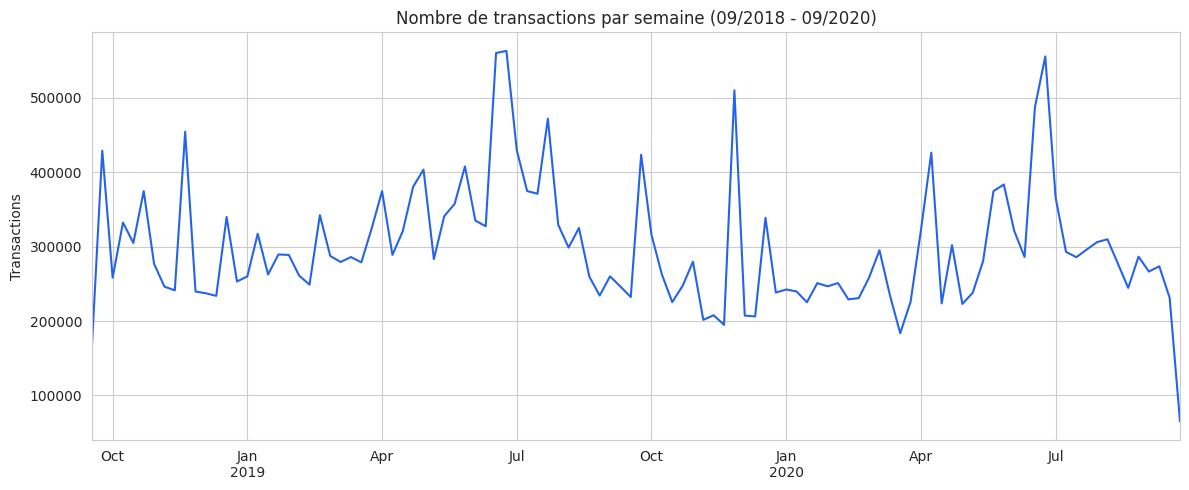

In [14]:
import matplotlib.dates as mdates

weekly_series = pd.Series(weekly_counts).sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
weekly_series.plot(ax=ax, color="#2563eb")
ax.set_title("Nombre de transactions par semaine (09/2018 - 09/2020)")
ax.set_ylabel("Transactions")
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** on observe des pics saisonniers réguliers (soldes, périodes de fêtes), et
une chute nette au printemps 2020, cohérente avec le ralentissement des ventes lié au début de la
pandémie de COVID-19, avant une reprise progressive.


### 9.2 Prix moyen dépensé par tranche d'âge

In [15]:
price_by_age = pd.DataFrame({
    "nb_achats": count_by_age,
    "prix_moyen": {k: price_sum_by_age[k] / v for k, v in count_by_age.items()},
}).sort_index()
price_by_age


,nb_achats,prix_moyen
16-19,691402,0.023569
20-24,5833649,0.026146
25-29,7224938,0.027950
30-34,4480388,0.028176
35-39,2088733,0.027665
40-49,4908363,0.027598
50-59,5136958,0.029403
60-69,1203826,0.030315
70+,220067,0.031197


Cette analyse met en évidence deux dimensions complémentaires :

- Les jeunes adultes (20–34 ans) représentent le cœur du volume d'achat et constituent un segment stratégique pour les modèles de recommandation en raison de leur forte activité.
- Les clients plus âgés génèrent moins de transactions, mais leurs achats présentent une valeur moyenne légèrement supérieure.

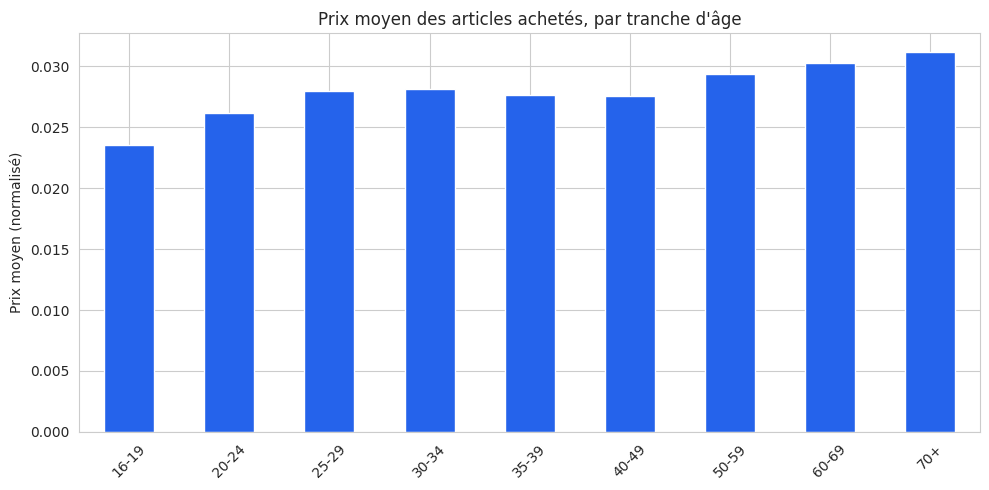

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
price_by_age["prix_moyen"].plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Prix moyen des articles achetés, par tranche d'âge")
ax.set_ylabel("Prix moyen (normalisé)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** le prix moyen augmente légèrement avec l'âge (les 70+ dépensent en moyenne
~30% de plus par article que les 16-19 ans), mais reste globalement stable entre 25 et 60 ans. Les
tranches jeunes (16-24 ans) achètent des articles un peu moins chers en moyenne, cohérent avec un
pouvoir d'achat plus limité et/ou une préférence pour des collections plus abordables (Divided).


### 9.3 Catégories de produits les plus achetées par tranche d'âge

In [17]:
age_category = pd.Series(count_by_age_category)
age_category.index = pd.MultiIndex.from_tuples(age_category.index, names=["age_group", "product_group_name"])
age_category_table = age_category.unstack(fill_value=0)

# Top catégorie par tranche d'âge
top_category_by_age = age_category_table.idxmax(axis=1)
top_category_by_age


,0
age_group,
16-19,Garment Upper body
20-24,Garment Upper body
25-29,Garment Upper body
30-34,Garment Upper body
35-39,Garment Upper body
40-49,Garment Upper body
50-59,Garment Upper body
60-69,Garment Upper body
70+,Garment Upper body


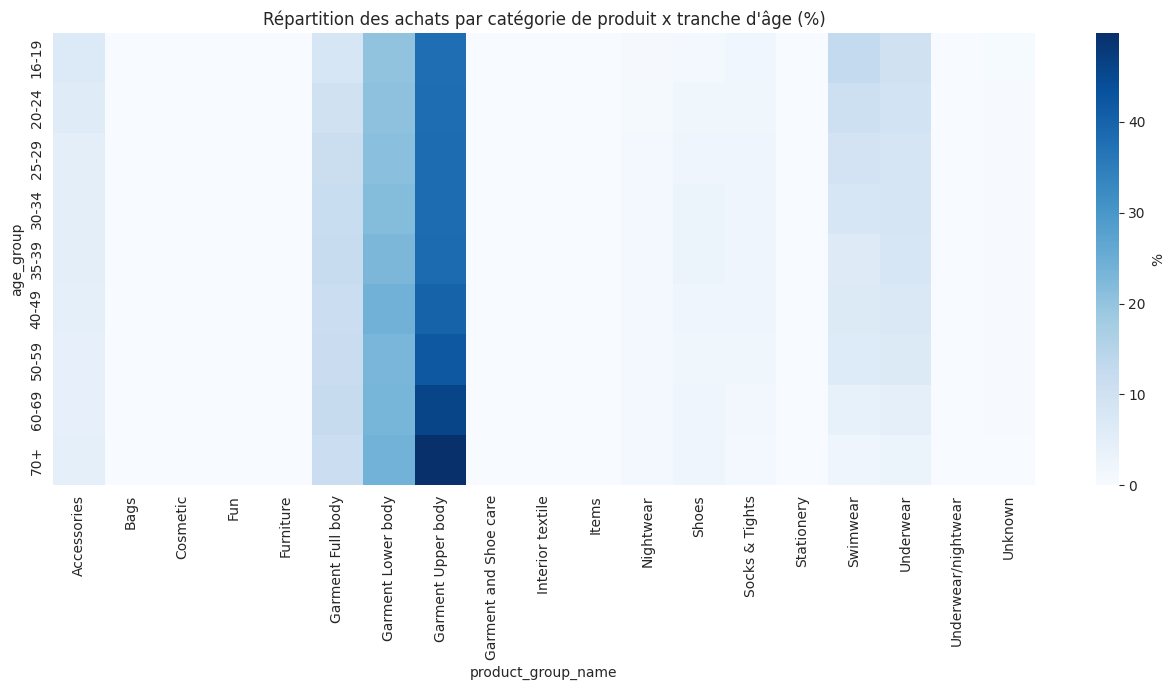

In [18]:
age_category_pct = age_category_table.div(age_category_table.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(age_category_pct.round(1), cmap="Blues", cbar_kws={"label": "%"}, ax=ax)
ax.set_title("Répartition des achats par catégorie de produit x tranche d'âge (%)")
plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation :** `Garment Upper body` est la catégorie la plus achetée sur quasiment toutes
les tranches d'âge, confirmant à la fois son poids dans le catalogue et son statut de valeur sûre.
On observe cependant des nuances selon l'âge (poids relatif de `Garment Lower body`, `Accessories`,
`Underwear` qui varie), utiles pour orienter des recommandations par segment démographique.


### 9.4 Comportement d'achat par statut club

In [19]:
purchase_by_status = pd.DataFrame({
    "nb_transactions": count_by_status,
    "nb_clients_acheteurs": {k: len(v) for k, v in customers_seen_by_status.items()},
})
purchase_by_status["achats_par_client"] = (
    purchase_by_status["nb_transactions"] / purchase_by_status["nb_clients_acheteurs"]
)
purchase_by_status["prix_moyen"] = {
    k: price_sum_by_status[k] / count_by_status[k] for k in count_by_status
}
purchase_by_status.round(2)


,nb_transactions,nb_clients_acheteurs,achats_par_client,prix_moyen
ACTIVE,31119566,1269237,24.52,0.03
PRE-CREATE,660219,92578,7.13,0.03
LEFT CLUB,8539,466,18.32,0.03


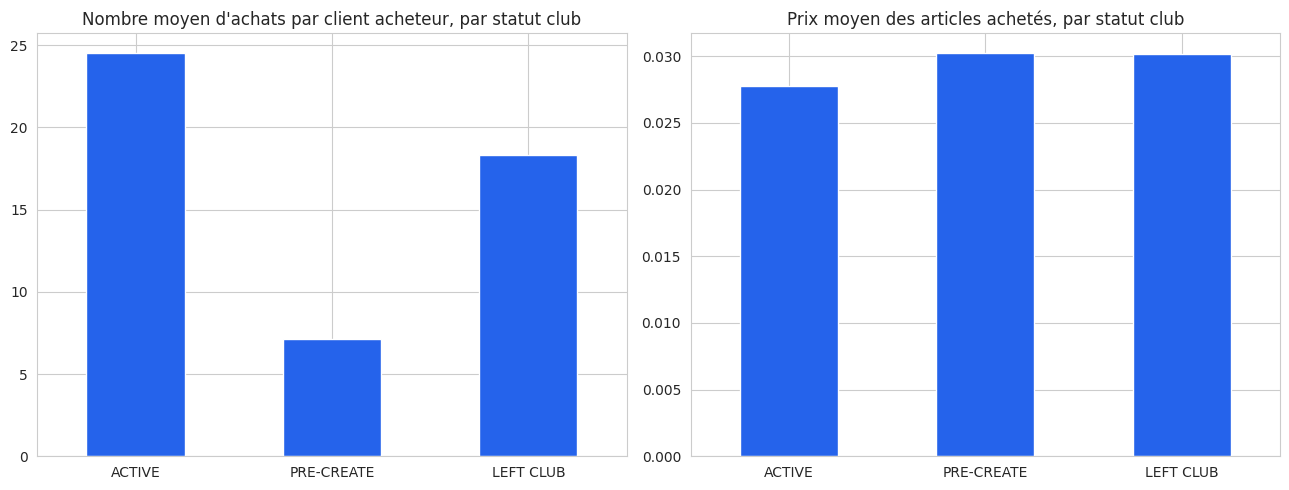

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

purchase_by_status["achats_par_client"].plot(kind="bar", ax=axes[0], color="#2563eb")
axes[0].set_title("Nombre moyen d'achats par client acheteur, par statut club")
axes[0].tick_params(axis='x', rotation=0)

purchase_by_status["prix_moyen"].plot(kind="bar", ax=axes[1], color="#2563eb")
axes[1].set_title("Prix moyen des articles achetés, par statut club")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
plt.close('all')


**Interprétation & hypothèse confirmée :** les clients `ACTIVE` achètent en moyenne **~26 fois**
sur la période (2 ans), contre seulement **~7 fois** pour les `PRE-CREATE`.

Un écart massif qui confirme que le statut club reflète un réel engagement d'achat, et pas seulement une inscription
administrative.

Le prix moyen par article est, lui, assez proche entre statuts (différence de quelques %), ce qui indique que l'écart entre statuts porte sur la **fréquence d'achat**, pas sur le positionnement prix des articles achetés.


### 9.5 Canal de vente (magasin vs en ligne)

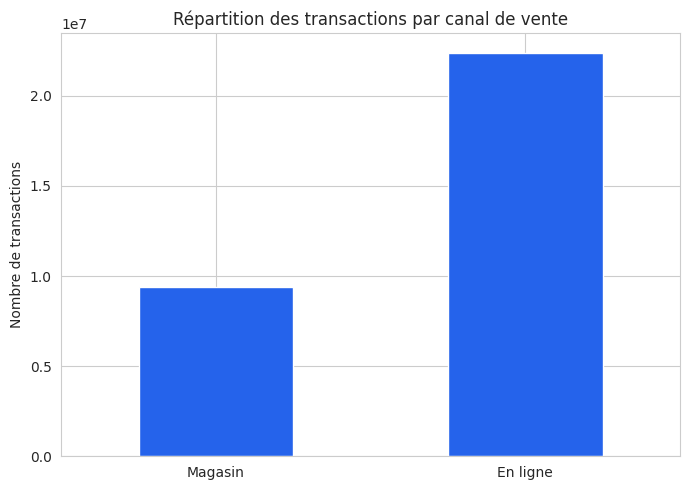

Magasin     29.6
En ligne    70.4
dtype: float64


In [21]:
channel_series = pd.Series(channel_counts).sort_index()
channel_series.index = channel_series.index.map({1: "Magasin", 2: "En ligne"})

fig, ax = plt.subplots(figsize=(7, 5))
channel_series.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Répartition des transactions par canal de vente")
ax.set_ylabel("Nombre de transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print((channel_series / channel_series.sum() * 100).round(1))
plt.close('all')


**Interprétation :** le canal **en ligne** domine largement (~70% des transactions), signe d'un
comportement d'achat déjà très digitalisé sur la période 2018-2020, avant même l'effet
d'accélération lié au COVID-19 visible en 2020 dans les données.


### 9.6 Top 10 des articles les plus vendus

In [22]:
top10_ids = sorted(article_counts.items(), key=lambda x: -x[1])[:10]
top10_df = pd.DataFrame(top10_ids, columns=["article_id", "nb_ventes"])
top10_df = top10_df.merge(articles[["article_id", "prod_name", "product_group_name"]], on="article_id", how="left")
top10_df


,article_id,nb_ventes,prod_name,product_group_name
0,706016001,50287,Jade HW Skinny Denim TRS,Garment Lower body
1,706016002,35043,Jade HW Skinny Denim TRS,Garment Lower body
2,372860001,31718,7p Basic Shaftless,Socks & Tights
3,610776002,30199,Tilly (1),Garment Upper body
4,759871002,26329,Tilda tank,Garment Upper body
5,464297007,25025,Greta Thong Mynta Low 3p,Underwear
6,372860002,24458,7p Basic Shaftless,Socks & Tights
7,610776001,22451,Tilly (1),Garment Upper body
8,399223001,22236,Curvy Jeggings HW Ankle,Garment Lower body
9,706016003,21241,Jade HW Skinny Denim TRS,Garment Lower body


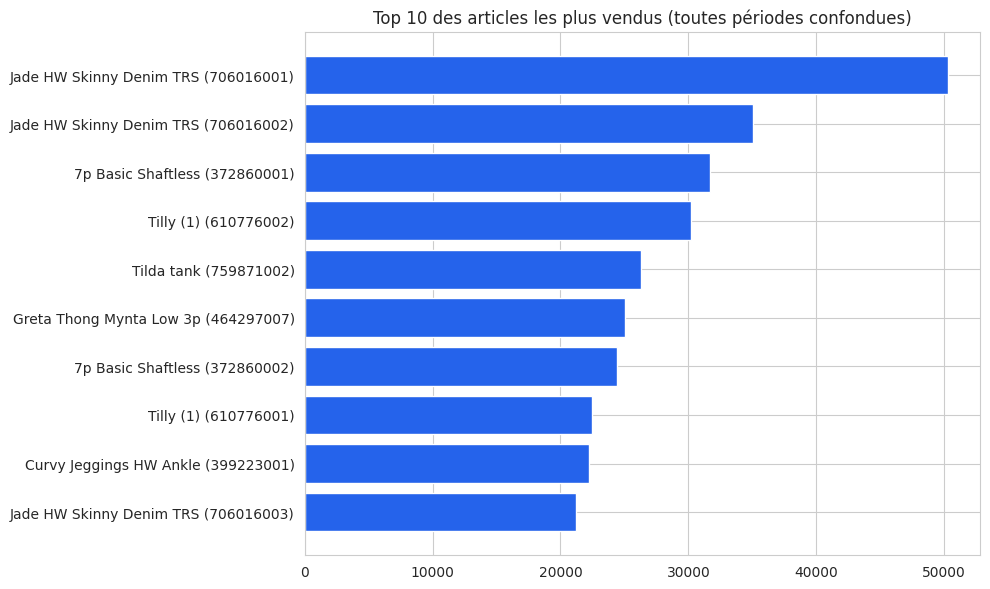

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_df["prod_name"] + " (" + top10_df["article_id"].astype(str) + ")",
        top10_df["nb_ventes"], color="#2563eb")
ax.set_title("Top 10 des articles les plus vendus (toutes périodes confondues)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close('all')


## 10. Synthèse finale — customers + articles + transactions

**Volumétrie**
- ~1,37M clients, ~105 500 articles au catalogue, **33,7M transactions** sur 2 ans (09/2018-09/2020).
- La quasi-totalité des clients référencés ont effectué au moins un achat sur la période.

**Comportement d'achat confirmé par les données réelles**
- Les clients `ACTIVE` achètent en moyenne **~26 fois** sur 2 ans contre **~7 fois** pour les
  `PRE-CREATE`, le statut club reflète un vrai engagement d'achat, pas juste une inscription.
- Le canal **en ligne** représente ~70% des transactions, largement devant le magasin physique.
- Le prix moyen dépensé par article augmente légèrement avec l'âge, mais reste stable dans
  l'ensemble ; l'écart entre statuts club porte sur la fréquence d'achat, pas sur le prix.
- `Garment Upper body` domine les achats sur toutes les tranches d'âge, cohérent avec son poids
  dans le catalogue.
- Chute visible des ventes au printemps 2020 (COVID-19), avec reprise progressive ensuite.

**Limites de la méthode**
- Par contrainte de mémoire (le fichier `transactions_train.csv` dépasse la RAM disponible), les
  statistiques ci-dessus ont été calculées par agrégation en streaming (traitement par blocs de 2M
  lignes), et non sur un DataFrame fusionné unique en mémoire. Les résultats sont exacts (calculés
  sur l'intégralité des 33,7M lignes, pas un échantillon), mais toute analyse nécessitant l'accès
  ligne par ligne au jeu de données fusionné complet (ex. modélisation par client) nécessiterait soit
  davantage de RAM, soit un moteur de traitement distribué (Dask, Spark) ou une base de données.

**Prochaine étape naturelle**
- Construire, toujours via le même traitement par blocs, des features par client (récence, fréquence,
  montant total, catégories préférées) en vue d'un modèle de recommandation, en gardant le format de
  sortie de `sample_submission.csv` comme objectif final (top-12 articles par client).


## Export vers les notebooks suivants

Les accumulateurs calculés pendant le passage par blocs sur `transactions_train.csv` (33,7M lignes)
sont réutilisés tels quels par les notebooks 03 et 04, pour éviter de relire ce fichier volumineux plusieurs fois.

> Les `defaultdict` sont convertis en `dict` simples avant export : un `defaultdict(lambda: ...)`
> n'est pas sérialisable avec `pickle` (une fonction lambda ne peut pas être picklée).

In [24]:
accumulators = {
    "customer_stats": dict(customer_stats),
    "daily_revenue": dict(daily_revenue),
    "daily_count": dict(daily_count),
    "product_group_revenue": dict(product_group_revenue),
    "article_counts": dict(article_counts),
    "channel_counts": dict(channel_counts),
    "customer_categories": dict(customer_categories),
    "customer_min_date": dict(customer_min_date),
    "customer_max_date": dict(customer_max_date),
    "total_rows": total_rows,
}
with open(os.path.join(INTERMEDIATE_DIR, "nb02_transactions_accumulators.pkl"), "wb") as f:
    pickle.dump(accumulators, f)

n_clients = len(accumulators["customer_stats"])
n_rows = accumulators["total_rows"]
print(f"Export -> nb02_transactions_accumulators.pkl ({n_clients:,} clients acheteurs, {n_rows:,} transactions)")


Export -> nb02_transactions_accumulators.pkl (1,362,281 clients acheteurs, 31,788,324 transactions)
